## Segmentaion_model_evaluation_and_visualization

#### Dataset & DataLoader

for the visualization i use an extra images "png" from other dataset 

In [17]:
from pathlib import Path
import re
import sys

import numpy as np
from PIL import Image
import torch
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms.functional as TF

# Resolve the project root from either the notebook directory or the workspace root.
cwd = Path.cwd().resolve()
if (cwd / "src").is_dir():
    PROJECT_ROOT = cwd
elif (cwd.parent / "src").is_dir():
    PROJECT_ROOT = cwd.parent
else:
    project_candidates = [
        path for path in [cwd, *cwd.parents] if (path / "src" / "data").is_dir()
    ]
    if not project_candidates:
        raise FileNotFoundError(
            "Could not locate PROJECT_ROOT containing src/data. "
            "Run this notebook from the project or notebooks directory."
        )
    PROJECT_ROOT = project_candidates[0]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

FLAIR_DIR = PROJECT_ROOT / "src" / "data" / "flairs"
MASK_DIR = PROJECT_ROOT / "src" / "data" / "masks"

if not FLAIR_DIR.is_dir() or not MASK_DIR.is_dir():
    raise FileNotFoundError(
        f"Expected dataset directories at {FLAIR_DIR} and {MASK_DIR}."
    )


def pairing_key(path: Path) -> str:
    """Normalize modality suffixes while preserving the full sample identifier."""
    key = path.stem.lower()
    key = re.sub(r"(?:__|_)(?:mask|fused)$", "", key)
    return key


class BrainTumorPNGDataset(Dataset):
    """RGBA BraTS PNG dataset using channel 3 as the FLAIR modality."""

    def __init__(self, flair_dir: Path, mask_dir: Path):
        flair_files = {
            pairing_key(path): path
            for path in sorted(Path(flair_dir).glob("*.png"))
        }
        mask_files = {
            pairing_key(path): path
            for path in sorted(Path(mask_dir).glob("*.png"))
        }

        common_keys = sorted(flair_files.keys() & mask_files.keys())
        if not common_keys:
            raise RuntimeError(
                f"No matching FLAIR/mask pairs found in {flair_dir} and {mask_dir}."
            )

        missing_masks = sorted(flair_files.keys() - mask_files.keys())
        missing_images = sorted(mask_files.keys() - flair_files.keys())
        if missing_masks or missing_images:
            print(
                f"Warning: skipped {len(missing_masks)} image(s) and "
                f"{len(missing_images)} mask(s) without a matching pair."
            )

        self.pairs = [(flair_files[key], mask_files[key]) for key in common_keys]

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):
        image_path, mask_path = self.pairs[index]

        # Read raw RGBA data and explicitly select index 3 (FLAIR).
        image_array = np.asarray(Image.open(image_path))
        if image_array.ndim != 3 or image_array.shape[2] < 4:
            raise ValueError(
                f"Expected an RGBA image for {image_path.name}, "
                f"received shape {image_array.shape}."
            )
        flair_channel = image_array[:, :, 3]
        image_tensor = TF.to_tensor(Image.fromarray(flair_channel))

        # Convert masks to one channel and binarize tumor tissue at 0.5.
        mask_tensor = (
            TF.to_tensor(Image.open(mask_path).convert("L")) > 0.5
        ).float()

        # Normalize only non-zero brain pixels; background air remains exactly zero.
        brain_pixels = image_tensor > 0
        if brain_pixels.any():
            mean = image_tensor[brain_pixels].mean()
            std = image_tensor[brain_pixels].std()
            image_tensor[brain_pixels] = (image_tensor[brain_pixels] - mean) / (
                std + 1e-8
            )

        has_tumor = torch.tensor(
            int(mask_tensor.sum().item() > 0), dtype=torch.long
        )
        return image_tensor, mask_tensor, has_tumor


# Keep every paired file in the test directory; no aggressive slice filtering.
dataset = BrainTumorPNGDataset(FLAIR_DIR, MASK_DIR)
loader = DataLoader(
    dataset,
    batch_size=len(dataset),
    shuffle=False,
    num_workers=0,
)

sample_images, sample_masks, sample_targets = next(iter(loader))
if sample_images.ndim != 4 or sample_images.shape[1] != 1:
    raise RuntimeError(f"Expected image batch shape (N, 1, H, W), got {sample_images.shape}.")

print(
    f"Dataset ready: {len(dataset)} paired sample(s), "
    f"image batch {tuple(sample_images.shape)}, "
    f"mask batch {tuple(sample_masks.shape)}."
)

Dataset ready: 10 paired sample(s), image batch (10, 1, 240, 240), mask batch (10, 1, 240, 240).


#### model and weights loading : 

In [20]:
import torch

from src.models.unet_segmentation import UNet


def find_checkpoint(project_root: Path) -> Path:
    """Find the trained segmentation checkpoint in common project locations."""
    preferred_paths = [
        project_root / "models" / "best_model.pth",
        project_root / "best_model.pth",
        project_root / "outputs" / "checkpoints" / "best_model.pth",
        project_root / "outputs" / "checkpoints" / "best_model.zip",
    ]
    for candidate in preferred_paths:
        if candidate.is_file():
            return candidate

    candidates = sorted(
        path
        for pattern in ("*.pth", "*.pt", "*.zip")
        for path in project_root.rglob(pattern)
        if "data" not in path.parts
    )
    if not candidates:
        raise FileNotFoundError(
            f"No segmentation checkpoint found under {project_root}."
        )
    return candidates[0]


def load_state_dict(checkpoint_path: Path, device: torch.device):
    """Load a raw state dict or a training checkpoint containing one."""
    try:
        checkpoint = torch.load(
            checkpoint_path,
            map_location=device,
            weights_only=False,
        )
    except TypeError:
        checkpoint = torch.load(checkpoint_path, map_location=device)

    if isinstance(checkpoint, dict):
        for key in ("model_state_dict", "state_dict", "model"):
            if key in checkpoint and isinstance(checkpoint[key], dict):
                checkpoint = checkpoint[key]
                break

    if not isinstance(checkpoint, dict) or not all(
        isinstance(key, str) for key in checkpoint
    ):
        raise TypeError(
            f"Checkpoint {checkpoint_path} does not contain a valid state dict."
        )

    return {
        key[7:] if key.startswith("module.") else key: value
        for key, value in checkpoint.items()
    }


try:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    checkpoint_path = find_checkpoint(PROJECT_ROOT)
    state_dict = load_state_dict(checkpoint_path, device)

    # This is the exact segmentation architecture used by the repository.
    model = UNet(in_channels=1, out_channels=1).to(device)
    model.load_state_dict(state_dict, strict=True)
    model.eval()
except Exception as error:
    raise RuntimeError(
        f"Could not load the segmentation U-Net checkpoint: {error}"
    ) from error

print(
    f"Segmentation model ready: {type(model).__name__} | "
    f"checkpoint: {checkpoint_path} | device: {device}"
)

Segmentation model ready: UNet | checkpoint: C:\Users\aimen\OneDrive\Desktop\multimodal-brain-tumor-diagnostics\outputs\checkpoints\best_model.zip | device: cpu


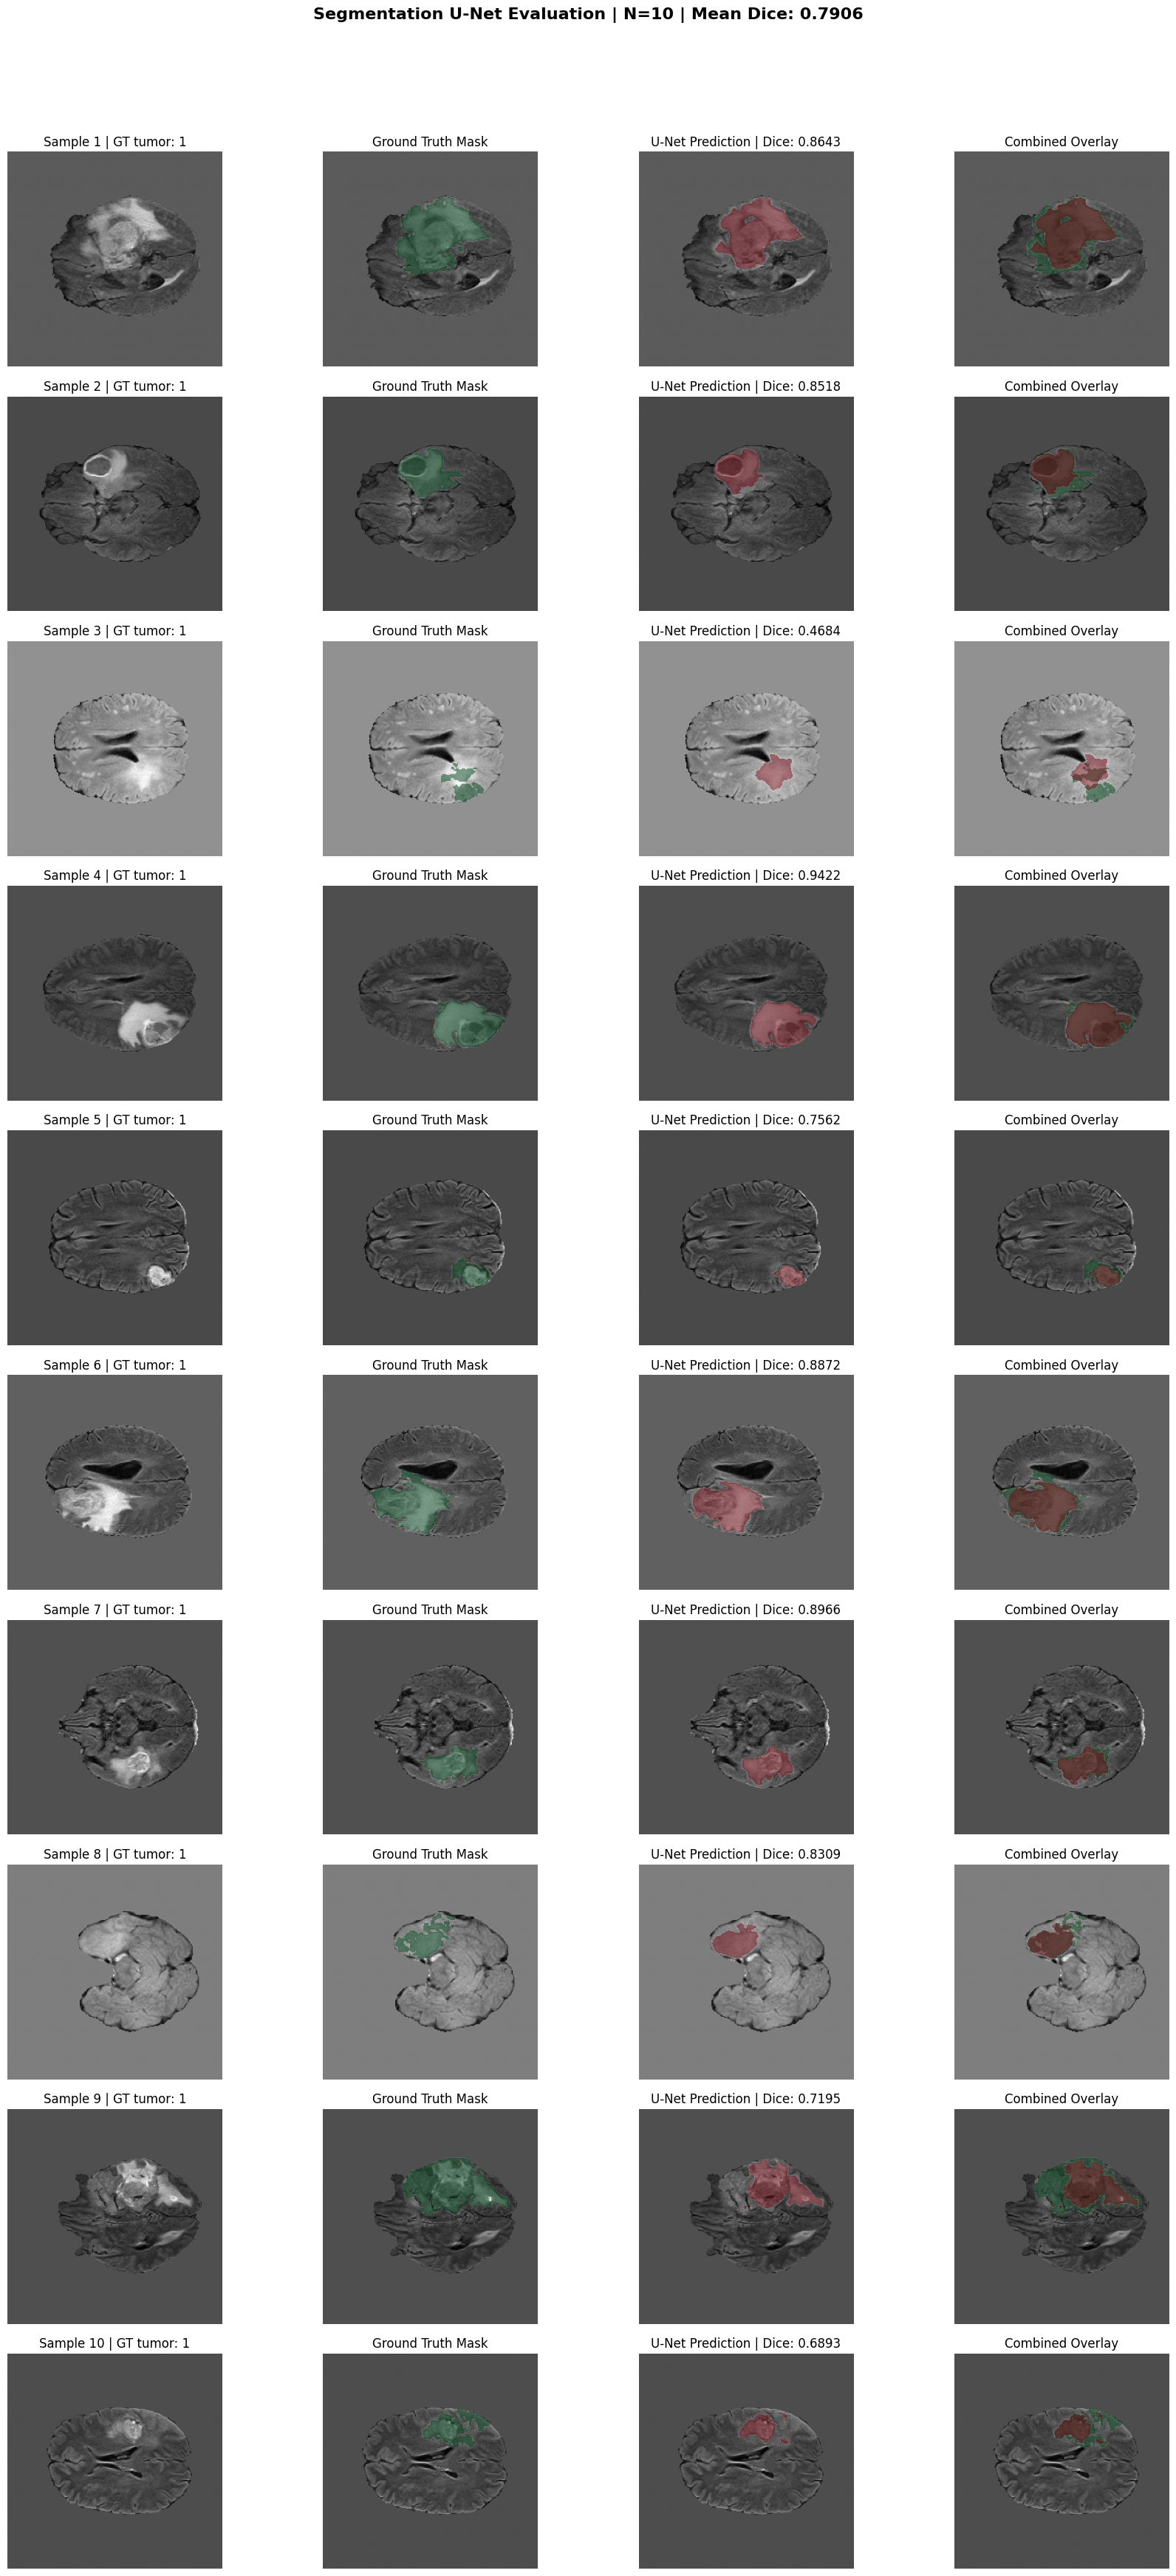

Segmentation inference complete: 10 sample(s) loaded; mean batch Dice = 0.7906.


In [21]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display


def dice_per_sample(predictions, targets, epsilon=1e-8):
    predictions = predictions.flatten(start_dim=1).float()
    targets = targets.flatten(start_dim=1).float()
    intersections = (predictions * targets).sum(dim=1)
    denominators = predictions.sum(dim=1) + targets.sum(dim=1)
    return (2.0 * intersections + epsilon) / (denominators + epsilon)


try:
    total_samples = len(dataset)
    if total_samples == 0:
        raise RuntimeError("The dataset contains no paired samples.")

    # The DataLoader contains the complete dataset in one deterministic batch.
    images, masks, targets = next(iter(loader))
    if images.shape[0] != total_samples:
        raise RuntimeError(
            f"Expected one batch containing {total_samples} samples, "
            f"received {images.shape[0]}."
        )

    with torch.inference_mode():
        segmentation_logits = model(images.to(device))
        if isinstance(segmentation_logits, (tuple, list, dict)):
            raise TypeError(
                "The loaded repository model is expected to return segmentation "
                "logits only, but returned a structured output."
            )

        if segmentation_logits.shape[1] == 1:
            predicted_masks = (torch.sigmoid(segmentation_logits) > 0.5).float()
        else:
            predicted_masks = (
                torch.argmax(segmentation_logits, dim=1, keepdim=True) > 0
            ).float()

    images_np = images.numpy()
    masks_np = masks.numpy()
    predictions_np = predicted_masks.cpu().numpy()
    dice_scores = dice_per_sample(predicted_masks.cpu(), masks).numpy()
    mean_dice = float(dice_scores.mean())

    # One figure with N rows and four segmentation diagnostic columns.
    figure, axes = plt.subplots(
        total_samples,
        4,
        figsize=(18, max(8, 3.5 * total_samples)),
        squeeze=False,
    )

    for sample_index in range(total_samples):
        image = images_np[sample_index, 0]
        ground_truth = masks_np[sample_index, 0]
        prediction = predictions_np[sample_index, 0]
        ground_truth_label = int(targets[sample_index].item())

        axes[sample_index, 0].imshow(image, cmap="gray")
        axes[sample_index, 0].set_title(
            f"Sample {sample_index + 1} | GT tumor: {ground_truth_label}"
        )
        axes[sample_index, 0].axis("off")

        axes[sample_index, 1].imshow(image, cmap="gray")
        axes[sample_index, 1].imshow(
            ground_truth,
            cmap="Greens",
            alpha=0.5 * (ground_truth > 0),
            vmin=0,
            vmax=1,
        )
        axes[sample_index, 1].set_title("Ground Truth Mask")
        axes[sample_index, 1].axis("off")

        axes[sample_index, 2].imshow(image, cmap="gray")
        axes[sample_index, 2].imshow(
            prediction,
            cmap="Reds",
            alpha=0.5 * (prediction > 0),
            vmin=0,
            vmax=1,
        )
        axes[sample_index, 2].set_title(
            f"U-Net Prediction | Dice: {dice_scores[sample_index]:.4f}"
        )
        axes[sample_index, 2].axis("off")

        axes[sample_index, 3].imshow(image, cmap="gray")
        axes[sample_index, 3].imshow(
            ground_truth,
            cmap="Greens",
            alpha=0.5 * (ground_truth > 0),
            vmin=0,
            vmax=1,
        )
        axes[sample_index, 3].imshow(
            prediction,
            cmap="Reds",
            alpha=0.5 * (prediction > 0),
            vmin=0,
            vmax=1,
        )
        axes[sample_index, 3].set_title("Combined Overlay")
        axes[sample_index, 3].axis("off")

    figure.suptitle(
        f"Segmentation U-Net Evaluation | N={total_samples} | "
        f"Mean Dice: {mean_dice:.4f}",
        fontsize=16,
        fontweight="bold",
        y=0.995,
    )
    figure.tight_layout(
        rect=(0, 0, 1, 0.96),
        h_pad=1.3,
        w_pad=1.0,
    )
    display(figure)
    plt.close(figure)

    print(
        f"Segmentation inference complete: {total_samples} sample(s) loaded; "
        f"mean batch Dice = {mean_dice:.4f}."
    )
except Exception as error:
    raise RuntimeError(f"Segmentation inference failed: {error}") from error